In [ ]:
# imports, file paths, MODEL_CONFIGS, cuda

import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum


import training_runtime 
import inference_runtime
from rms_norm import RMSNorm


MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "batch_size"  : 2**4,   # 16
    "vocab_size"  : 2**11,  # 2048
    "learning_rate" : 1e-3,
    "save_path" : "../models/level4_multi_head_attn.pt",
    "loss_history" : "../models/level4_multi_head_attn_loss_history.txt",

    "num_attn_heads": 2**2, #8
}



# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)




cuda


In [6]:
class Level4MultiHeadAttentionModel(nn.Module):
    """
    Input:
        idx: Long(Int) tensor with shape (batch, seq_len)

    Output:
        logits: Float tensor with shape (batch, seq_len, vocab_size)
    """

    def __init__(self):
        super().__init__()
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        self.vocab_size = MODEL_CONFIGS["vocab_size"]
        self.max_seq_len = MODEL_CONFIGS["max_seq_len"]
        self.num_attn_heads = MODEL_CONFIGS["num_attn_heads"]

        # Token Embedding lookup (learnable parameters)
        self.embed = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)

        # Unembedding Projection matrix (learnable parameters)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)

        # pos_enc: (max_seq_len, embed_dim)
        pos_enc = self.build_sinusoidal_positional_encoding(
            max_seq_len=self.max_seq_len,
            embed_dim=self.embed_dim,
        )

        # Register as buffer: non-learnable(no grad flows in)
        self.register_buffer('pos_enc', pos_enc)

        self.rms_norm_1 = RMSNorm(self.embed_dim)
        self.rms_norm_2 = RMSNorm(self.embed_dim)

        self.multi_attn = MultiHeadCausalAttention()


    @staticmethod
    def build_sinusoidal_positional_encoding(max_seq_len: int, embed_dim: int):
        """
        Returns:
            pos_enc: Float tensor with shape (max_seq_len, embed_dim)
        """
        pos_enc = torch.zeros(max_seq_len, embed_dim)
        position = torch.arange(0, max_seq_len, 
                                dtype=torch.float).unsqueeze(1) # shape: (max_seq_len, 1)
        
        # geometric progression division term: 10000^(2i/embed_dim)
        # operating in log-space for numerical stability
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() 
                             * (-math.log(10000.0) / embed_dim)) # shape: (embed_dim/2)

        # even(%2==0) dimensions get sine.
        pos_enc[:, 0::2] = torch.sin(position * div_term)

        # odd dimensions get cosine.
        # slice div_term in case embed_dim is odd.
        pos_enc[:, 1::2] = torch.cos(position * div_term[: pos_enc[:, 1::2].shape[1]])
        
        return pos_enc




    def forward(self, idx):
        batch_size, seq_len = idx.shape

        # Look up and add fixed positional encodings
        x_token = self.embed[idx]

        # x_pos: (1, seq_len, embed_dim)
        # add 1 so to broadcast over batch
        x_pos = rearrange(
            self.pos_enc[:seq_len],
            "seq_len embed_dim -> 1 seq_len embed_dim",
        )

        # x: (batch, seq_len, embed_dim)
        x = x_token + x_pos  # PyTorch automatically broadcasts the batch dimension of 1 to batch_size

        # pre-norm attention block.
        # x_norm_1: (batch, seq_len, embed_dim)
        x_norm_1 = self.rms_norm_1(x)

        # attn_out: (batch, seq_len, embed_dim)
        attn_out = self.multi_attn(x_norm_1)

        # Residual connection.
        # x: (batch, seq_len, embed_dim)
        x = x + attn_out

        # x_norm_2: (batch, seq_len, embed_dim)
        x_norm_2 = self.rms_norm_2(x)

        # logits: (batch, seq_len, vocab_size)
        logits = einsum(
            x_norm_2,
            self.unembed,
            "batch seq_len embed_dim, embed_dim vocab_size -> batch seq_len vocab_size",
        )

        return logits



In [ ]:
class MultiHeadCausalAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.num_heads = MODEL_CONFIGS["num_attn_heads"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]


        assert self.embed_dim % self.num_heads == 0, "embed_dim must be divisible by num_heads"

        self.head_dim = self.embed_dim // self.num_heads


        #  query, key, value projections
        self.query_proj = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)
        self.key_proj   = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)
        self.value_proj = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)

        # output projection
        self.out_proj   = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)



    def forward(self, x):
        batch, seq_len, embed_dim = x.shape

        # project through
        q = einsum(x, self.query_proj, "batch seq_len embed_dim, embed_dim d_out -> batch seq_len d_out")
        k = einsum(x, self.key_proj,   "batch seq_len embed_dim, embed_dim d_out -> batch seq_len d_out")
        v = einsum(x, self.value_proj, "batch seq_len embed_dim, embed_dim d_out -> batch seq_len d_out")


        # split into heads
        q = rearrange(q, "batch seq_len (num_heads head_dim) -> batch num_heads seq_len head_dim", 
                      num_heads=self.num_heads, head_dim=self.head_dim)
        
        k = rearrange(k, "batch seq_len (num_heads head_dim) -> batch num_heads seq_len head_dim", 
                      num_heads=self.num_heads, head_dim=self.head_dim)
        
        v = rearrange(v, "batch seq_len (num_heads head_dim) -> batch num_heads seq_len head_dim", 
                      num_heads=self.num_heads, head_dim=self.head_dim)


        # scaled dot-product attention
        attn_scores = einsum(q, k, 
                             "batch num_heads query_seq head_dim, batch num_heads key_seq head_dim " 
                             "->" 
                             " batch num_heads query_seq key_seq") / math.sqrt(self.head_dim)


        # causal masking
        causal_mask = torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool).triu(diagonal=1)
        attn_scores = attn_scores.masked_fill(causal_mask, float("-inf"))

        # attention probabilities
        attn_weights = torch.nn.functional.softmax(attn_scores, dim=-1)


        # weighted sum of values
        attn_output = einsum(
            attn_weights, v,
            "batch num_heads query_seq key_seq, batch num_heads key_seq head_dim" 
            "->" 
            "batch num_heads query_seq head_dim"
        )

        # merge heads
        # (batch, num_heads, seq_len, head_dim) -> (batch, seq_len, embed_dim)
        attn_output = rearrange(
            attn_output,
            "batch num_heads seq_len head_dim -> batch seq_len (num_heads head_dim)"
        )



        # Output projection
        output = einsum(
            attn_output, self.out_proj,
            "batch seq_len embed_dim, embed_dim d_out -> batch seq_len d_out"
        )

        return output


Step 0000 | Batch Loss: 7.6367 nats
Step 0005 | Batch Loss: 7.5854 nats
Step 0010 | Batch Loss: 7.5464 nats
Step 0015 | Batch Loss: 7.5011 nats
Step 0020 | Batch Loss: 7.4443 nats
Step 0025 | Batch Loss: 7.3762 nats
Step 0030 | Batch Loss: 7.3119 nats
Step 0035 | Batch Loss: 7.3042 nats
Step 0040 | Batch Loss: 7.2333 nats
Step 0045 | Batch Loss: 7.1730 nats
Step 0050 | Batch Loss: 7.1369 nats
Step 0055 | Batch Loss: 7.1442 nats
Step 0060 | Batch Loss: 7.0989 nats
Step 0065 | Batch Loss: 7.0387 nats
Step 0070 | Batch Loss: 7.0896 nats
Step 0075 | Batch Loss: 7.0632 nats
Step 0080 | Batch Loss: 7.0095 nats
Step 0085 | Batch Loss: 7.0647 nats
Step 0090 | Batch Loss: 7.0910 nats
Step 0095 | Batch Loss: 7.1058 nats
Step 0099 | Batch Loss: 7.0278 nats

Saving model weights to: ../models/level4.1_multi_head_attn.pt
Loss history successfully saved to ../models/level4.1_multi_head_attn_loss_history.txt
Loaded 100 steps from ../models/level4.1_multi_head_attn_loss_history.txt


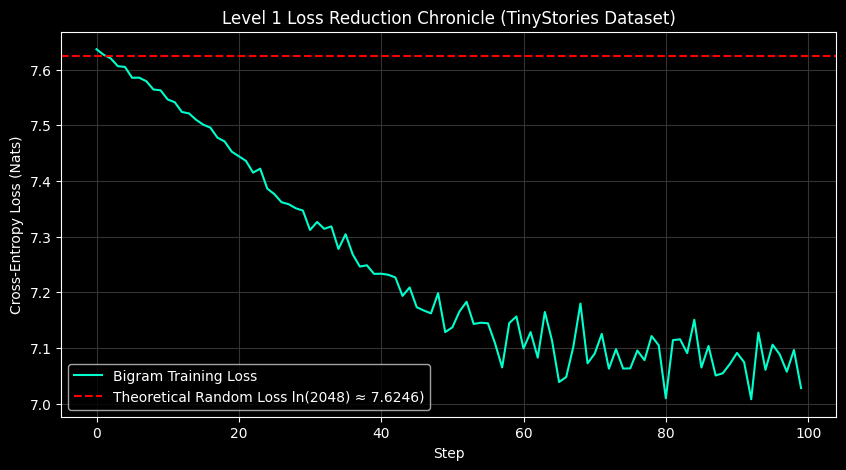

In [11]:
model = Level4MultiHeadAttentionModel()
configs = MODEL_CONFIGS

training_runtime.train_and_save_model(model, configs, device, 100)
training_runtime.plot_loss_history(configs)
